In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load
df = pd.read_csv('../data/loan_data.csv')
df = df.drop(columns=['Unnamed: 0'])  # drop index column
df = df.rename(columns={'SeriousDlqin2yrs': 'default'})

print(df.shape)
df.head()

(150000, 11)


,default,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


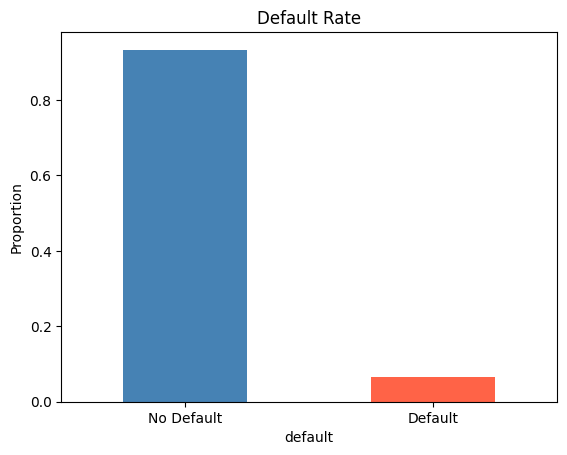

default
0    0.93316
1    0.06684
Name: proportion, dtype: float64


In [2]:
# Class balance — critical for fraud/default problems
df['default'].value_counts(normalize=True).plot(kind='bar', color=['steelblue','tomato'])
plt.title('Default Rate')
plt.ylabel('Proportion')
plt.xticks([0,1], ['No Default', 'Default'], rotation=0)
plt.show()

print(df['default'].value_counts(normalize=True))

In [3]:
# Missing values
missing = df.isnull().sum()
print(missing[missing > 0])

MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64


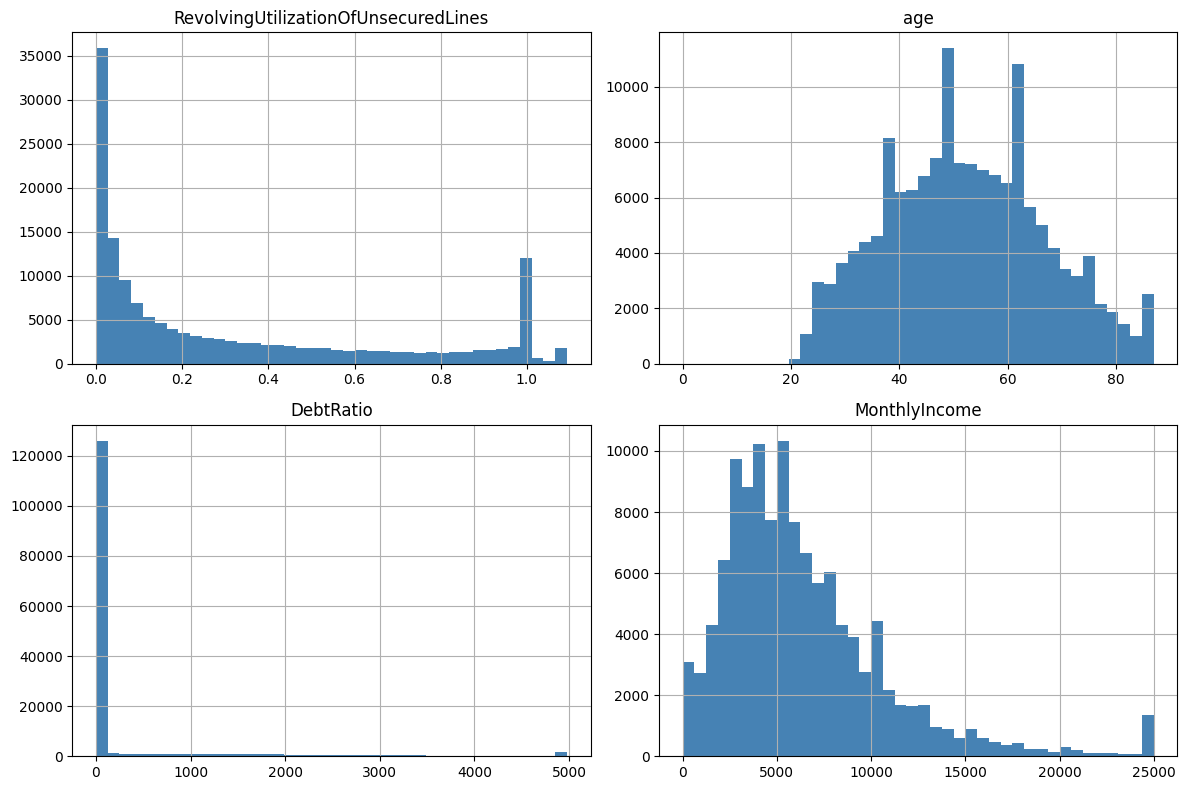

In [4]:
# Distributions of key features
features = ['RevolvingUtilizationOfUnsecuredLines',
            'age', 'DebtRatio', 'MonthlyIncome']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), features):
    df[col].clip(upper=df[col].quantile(0.99)).hist(ax=ax, bins=40, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()